# Land-cover Segmentation — putting pixels where cartography ran out

The companion notebook ([`notebook.ipynb`](notebook.ipynb)) took forest
land-cover classification as far as *cartographic* features allow: a
random forest at 0.95 accuracy for in-region infill, with one stubborn
residual — Spruce/Fir versus Lodgepole Pine — that elevation, slope and
soil simply cannot separate. The closing line of that analysis was that
the residual is a **data** problem, not a model problem, and that the data
that resolves it is **imagery**.

This notebook is the other half of that argument. It moves from a table of
covariates to the raw pixels of **0.25–0.5 m aerial imagery**, and from
predicting one label per patch to predicting **a label for every pixel** —
semantic segmentation. The tool is a **PyTorch U-Net with an
ImageNet-pretrained ResNet-34 encoder**, trained on the open
[LandCover.ai](https://landcover.ai.linuxpolska.com/) dataset. The same
disciplines carry over: form the problem honestly, respect the class
imbalance, and report the metric that survives it — here, **intersection-
over-union**, the segmentation analogue of the macro-F1 that did the
honest work in the tabular notebook.

## 1. Introduction

*From patches to pixels, and why segmentation is the right frame.*

A vegetation-monitoring platform does not want one label for a 30 m
square; it wants a **wall-to-wall map** — every pixel of a drone or
satellite mosaic assigned to a land-cover class, so that areas, boundaries
and change can be measured directly. That is semantic segmentation: a
dense, per-pixel classification of the image.

Three things make it the harder, more honest problem, and each has a
direct echo in the tabular notebook:

1. **Spatial structure is the signal, not a nuisance.** A pixel's class
   depends on its neighbours — texture, shape, context. A model has to
   *see*, which is why this is a convolutional, not a tabular, problem.
2. **The classes are brutally imbalanced.** Woodland and background cover
   most pixels; buildings and roads are slivers. Pixel accuracy is as
   misleading here as raw accuracy was in the tabular notebook — a model
   that paints everything "background or woodland" already scores well.
   The fix is the same in spirit: score every class on equal footing
   (per-class IoU and mIoU).
3. **Honesty about generalisation.** We keep whole orthophotos out of
   training, so the test tiles come from scenes the model has never seen —
   the imagery version of the leave-one-region-out check from §4.5 of the
   tabular notebook.

The plan: look hard at the data and its imbalance (§2), build and train a
transfer-learned U-Net (§3), then read its per-class IoU, pixel confusion,
and qualitative predictions against that honest standard (§4).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import seg_data as sd
import seg_models as sm
import seg_plots as sp
from plots import apply_style, kpi_banner
apply_style()

DEVICE = sm.resolve_device()
print("torch", torch.__version__, "| device:", DEVICE)

# Geographic (by-orthophoto) split — whole scenes never cross train/val/test.
groups = sd.orthophoto_split(seed=0)
print("orthophotos  train {}  val {}  test {}  (train/test disjoint: {})".format(
    len(groups["train"]), len(groups["val"]), len(groups["test"]),
    groups["train"].isdisjoint(groups["test"])))

cache = sd.prepare(size=256, n_train=1200, n_val=350, n_test=350, seed=0)
train_ds = sd.LandCoverTiles(cache, "train", augment=True)
val_ds   = sd.LandCoverTiles(cache, "val")
test_ds  = sd.LandCoverTiles(cache, "test")
print(f"tiles  train {len(train_ds)}  val {len(val_ds)}  test {len(test_ds)}")

torch 2.12.1 | device: mps
orthophotos  train 29  val 6  test 6  (train/test disjoint: True)


  [train] 29 orthophotos -> 1200 tiles


  [val] 6 orthophotos -> 350 tiles


  [test] 6 orthophotos -> 350 tiles
tiles  train 1200  val 350  test 350


## 2. Data

*What the imagery looks like, how it is split, and the imbalance that
dictates how we must score.*

LandCover.ai is 41 hand-labelled aerial orthophotos of Poland — **216 km²
at 0.25–0.5 m/pixel** — with five classes: background, building, woodland,
water, road. The published benchmark ships *tile* splits in which every
orthophoto contributes tiles to train, val **and** test — so a model can be
graded on tiles cut from a scene it trained on. We avoid that: we assign
**whole orthophotos** to train / val / test (29 / 6 / 6), borrowing the
published tile names only to know which 512 px grid cells are valid, then
crop those and downsample 512→256 px for a tractable budget. The result is a
genuine geographic holdout — the imagery analogue of Pillar 1's
leave-one-region-out test.

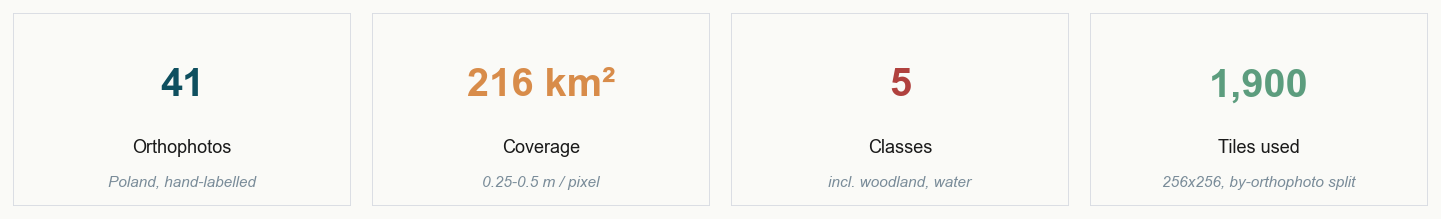

In [2]:
fig = kpi_banner([
    ("41",        "Orthophotos",   "Poland, hand-labelled"),
    ("216 km²",   "Coverage",      "0.25-0.5 m / pixel"),
    ("5",         "Classes",       "incl. woodland, water"),
    (f"{len(train_ds)+len(val_ds)+len(test_ds):,}", "Tiles used", "256x256, by-orthophoto split"),
])
plt.show()

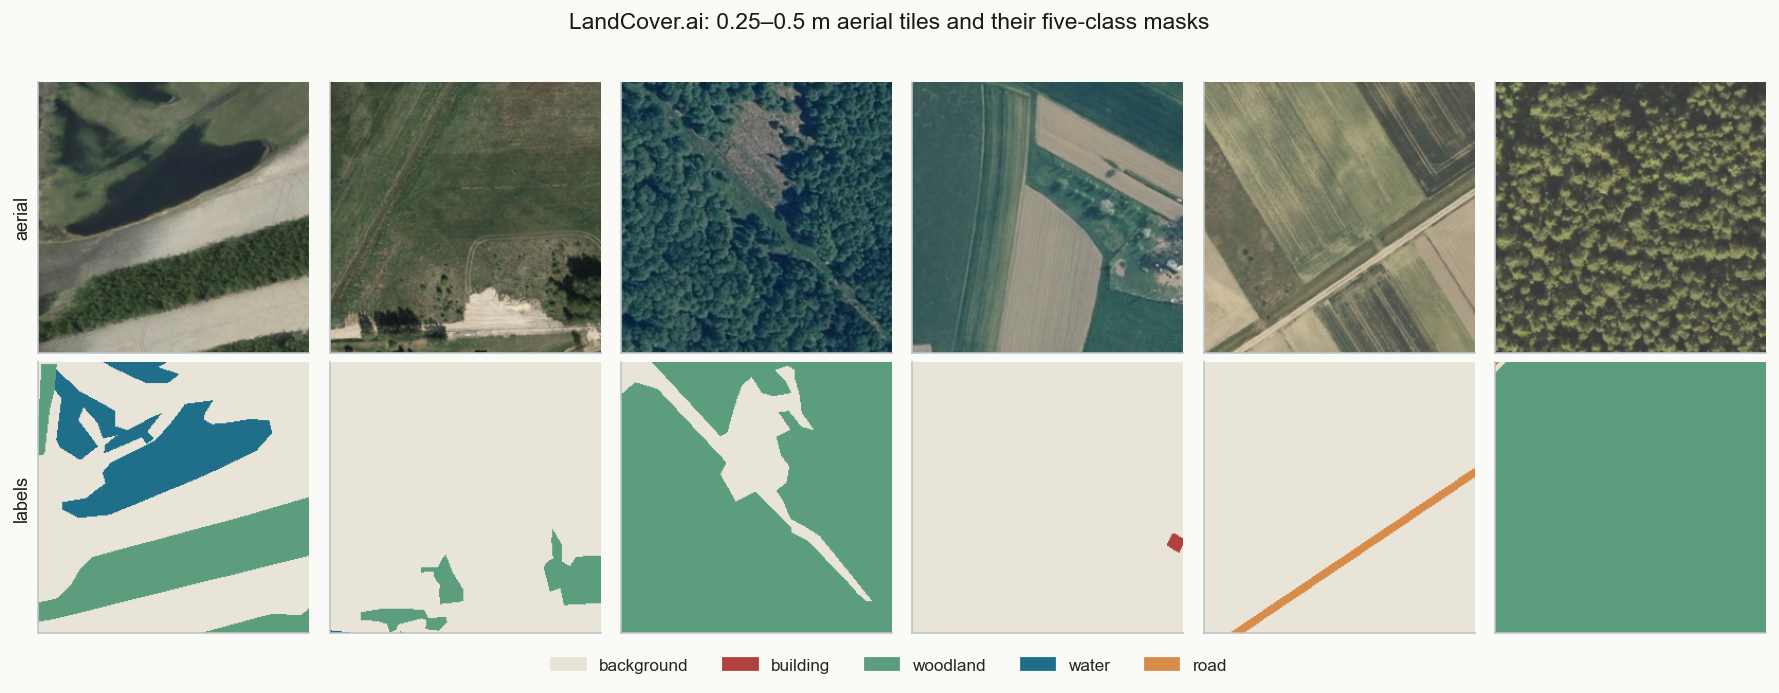

In [3]:
fig = sp.tile_gallery(train_ds, n=6, seed=1)
plt.show()

**What to look at.** Six aerial tiles (top) and their pixel-level
masks (bottom). The imagery is true-colour at sub-metre resolution — the
texture of a tree canopy, the straight edge of a field, the glint of
water are all legible to the eye, and therefore learnable by a
convolutional network.

**What it tells us.** The signal is *spatial*: woodland is a texture, a
road is a thin connected line, water is a smooth homogeneous region. None
of that survives flattening into a feature vector — which is exactly why
the tabular approach has a ceiling and this one does not share it.

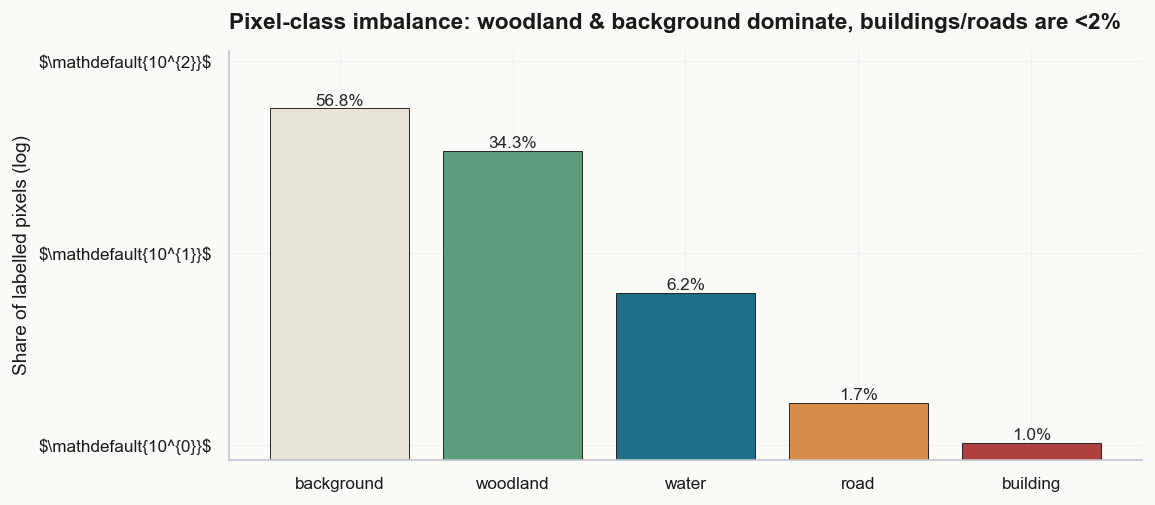

pixel share: {'background': '56.8%', 'building': '1.0%', 'woodland': '34.3%', 'water': '6.2%', 'road': '1.7%'}


In [4]:
fracs = sd.class_pixel_fractions(cache, "train")
fig, ax = plt.subplots(figsize=(9, 4))
sp.class_distribution_bar(fracs, ax=ax)
plt.tight_layout(); plt.show()
print("pixel share:", {n: f"{f*100:.1f}%" for n, f in zip(sd.CLASS_NAMES, fracs)})

**What the numbers say.** Woodland and background together are ~90%
of all labelled pixels; **buildings and roads are under 2% each**. This is
the same shape of problem as the tabular class imbalance (two species held
85% of the patches), and it has the same consequence: **a metric that
averages over pixels will be dominated by the easy majority**.

**Why IoU, not pixel accuracy.** A model that labels every pixel
"woodland or background" already scores ~90% pixel accuracy while being
useless for the classes anyone cares about. **Intersection-over-Union**
computed *per class* and then averaged (**mIoU**) refuses that free lunch:
it scores buildings and roads on equal footing with woodland. IoU is to
segmentation what macro-F1 was to the tabular problem — the metric that
cannot be gamed by ignoring the minorities. We also down-weight the
majority classes in the loss (inverse-frequency weighting) so the network
spends gradient on the rare ones.

## 3. Methods

*A transfer-learned U-Net — the right architecture for dense prediction on
a small labelled set.*

The model is a **U-Net**: an encoder that compresses the image into
increasingly abstract feature maps, and a decoder that upsamples back to
full resolution, **re-injecting the encoder's high-resolution feature maps
at each step** (the skip connections) so that fine boundaries survive the
round trip. The twist that makes it work on only ~1,200 tiles is **transfer
learning**: the encoder is a **ResNet-34 pretrained on ImageNet**, so it
arrives already knowing edges, textures and shapes. We fine-tune it at
one-tenth the decoder's learning rate — nudging the pretrained filters,
not overwriting them.

In [5]:
model = sm.UNetResNet34(sd.N_CLASSES, pretrained=True)
n_params = sum(p.numel() for p in model.parameters())
n_enc = sum(p.numel() for p in model.encoder_parameters())
print(f"U-Net (ResNet-34 encoder): {n_params/1e6:.1f}M params "
      f"({n_enc/1e6:.1f}M pretrained encoder + {(n_params-n_enc)/1e6:.1f}M decoder)")

# inverse-frequency class weights so the rare classes drive gradient too
weights = 1.0 / np.clip(fracs, 1e-4, None)
weights = weights / weights.sum() * sd.N_CLASSES
print("class loss weights:", {n: round(float(w), 2) for n, w in zip(sd.CLASS_NAMES, weights)})

U-Net (ResNet-34 encoder): 24.5M params (21.3M pretrained encoder + 3.2M decoder)
class loss weights: {'background': 0.05, 'building': 2.73, 'woodland': 0.08, 'water': 0.45, 'road': 1.68}


**The training recipe.** AdamW, cosine-annealed learning rate,
weighted cross-entropy, light geometric augmentation (flips and 90°
rotations — colour is left untouched because spectral values *are* the
signal). 14 epochs is a deliberately modest budget: enough to show the
method works and the curve's shape, while keeping the notebook
re-runnable. Watch the validation mIoU climb.

epoch  0  train_loss 0.909  val mIoU 0.250  val pixacc 0.430


epoch  1  train_loss 0.628  val mIoU 0.338  val pixacc 0.610


epoch  2  train_loss 0.507  val mIoU 0.395  val pixacc 0.722


epoch  3  train_loss 0.470  val mIoU 0.404  val pixacc 0.668


epoch  4  train_loss 0.456  val mIoU 0.422  val pixacc 0.724


...

epoch  9  train_loss 0.275  val mIoU 0.484  val pixacc 0.785


epoch 10  train_loss 0.274  val mIoU 0.491  val pixacc 0.795


epoch 11  train_loss 0.246  val mIoU 0.496  val pixacc 0.799


epoch 12  train_loss 0.246  val mIoU 0.493  val pixacc 0.795


epoch 13  train_loss 0.239  val mIoU 0.478  val pixacc 0.782


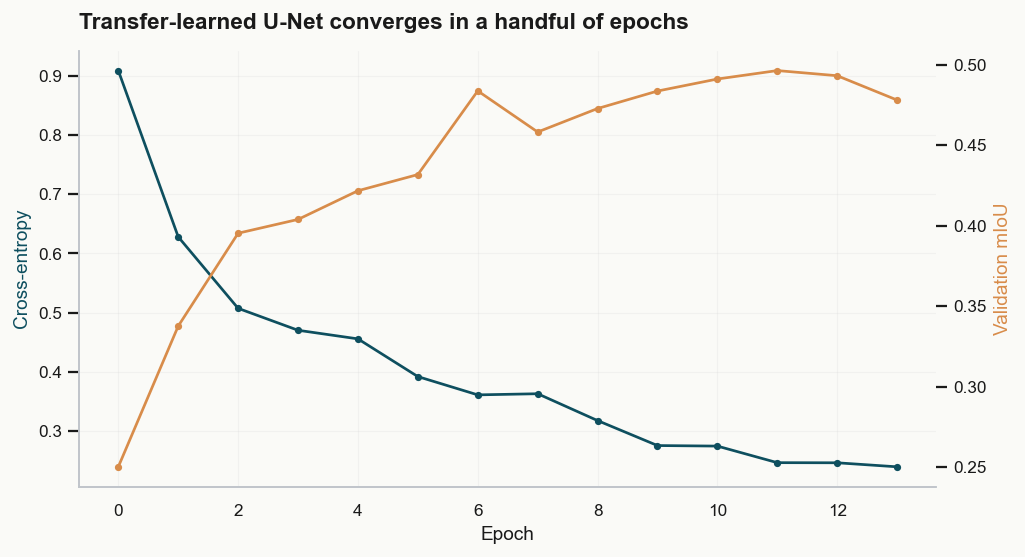

In [6]:
import numpy as np
np.random.seed(0)  # reproducible augmentation draws

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=16, num_workers=0)

history = sm.train_segmenter(
    model, train_loader, val_loader, sd.N_CLASSES, DEVICE,
    epochs=14, lr=1e-3, class_weights=weights, seed=0,
)

fig, ax = plt.subplots(figsize=(8, 4.4))
sp.training_curves(history, ax=ax)
plt.tight_layout(); plt.show()

**What the numbers say.** Validation mIoU rises fast in the first few
epochs — the payoff of the pretrained encoder, which starts from useful
filters rather than noise — then keeps climbing more slowly. **The curve
has not plateaued**, which is the segmentation echo of the random forest's
learning curve in the tabular notebook: there is headroom, and the lever
is more labelled tiles and more epochs, not a different architecture. For a
14-epoch budget on 1,200 tiles, the trajectory is exactly what a
transfer-learned U-Net should show.

## 4. Results

*Per-class IoU, the pixel confusion structure, and what the predictions
actually look like.*

test mIoU            : 0.590
test pixel accuracy  : 0.885
freq-weighted IoU    : 0.829

per-class   IoU  recall  precision
  background  0.87   0.89    0.98
  building    0.32   0.94    0.33
  woodland    0.80   0.88    0.90
  water       0.73   0.96    0.76
  road        0.23   0.83    0.24


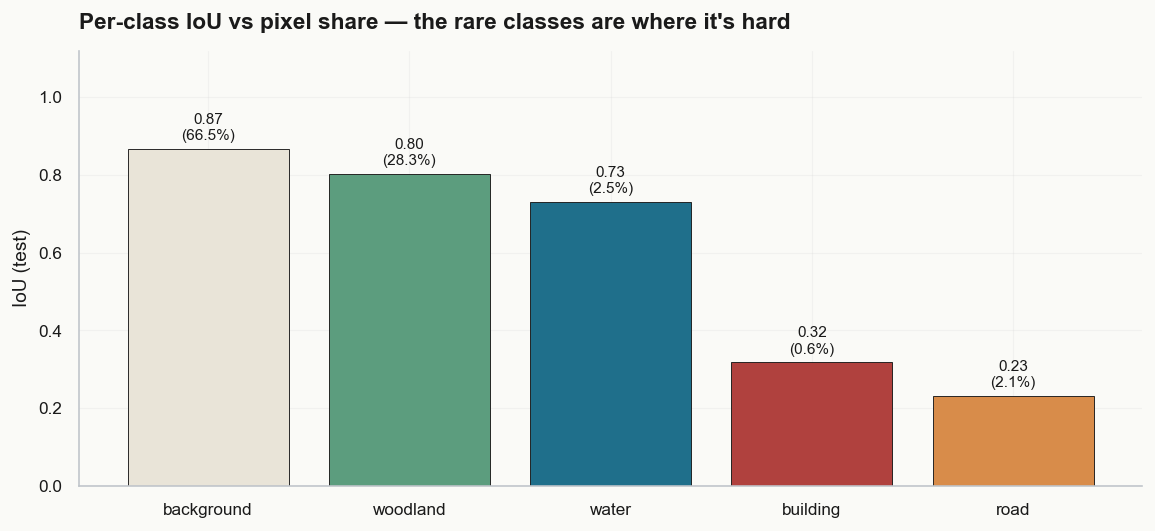

In [7]:
conf = sm.evaluate(model, test_loader, sd.N_CLASSES, DEVICE)
m = sm.metrics_from_confusion(conf)
print(f"test mIoU            : {m['miou']:.3f}")
print(f"test pixel accuracy  : {m['pixel_acc']:.3f}")
print(f"freq-weighted IoU    : {m['fw_iou']:.3f}")
print("\nper-class   IoU  recall  precision")
for n, io, rc, pr in zip(sd.CLASS_NAMES, m['per_class_iou'],
                         m['per_class_recall'], m['per_class_precision']):
    print(f"  {n:11s} {io:.2f}   {rc:.2f}    {pr:.2f}")

fig, ax = plt.subplots(figsize=(9, 4.2))
sp.per_class_iou_bar(m["per_class_iou"], m["support_frac"], ax=ax)
plt.tight_layout(); plt.show()

**What the numbers say.** Read the gap between **pixel accuracy** and
**mIoU**: pixel accuracy sits high because it is dominated by the easy
majority, while mIoU — the honest number — sits lower because it counts
the hard classes equally. The per-class bars tell the rest: the
homogeneous, abundant classes (**woodland**, **water**, **background**)
score well, while the thin, rare classes (**building**, **road**) are
where IoU falls.

But look at the printed recall column before concluding the model "can't
see" buildings and roads — **their recall is actually high**. What drags
their IoU down is *precision*: because we up-weighted them in the loss,
the network leans toward over-painting them, collecting false positives
from the surrounding background and woodland. IoU is the metric that nets
that recall-up / precision-down trade into one number, which is exactly
why it — not pixel accuracy, and not recall alone — is the figure to
report.

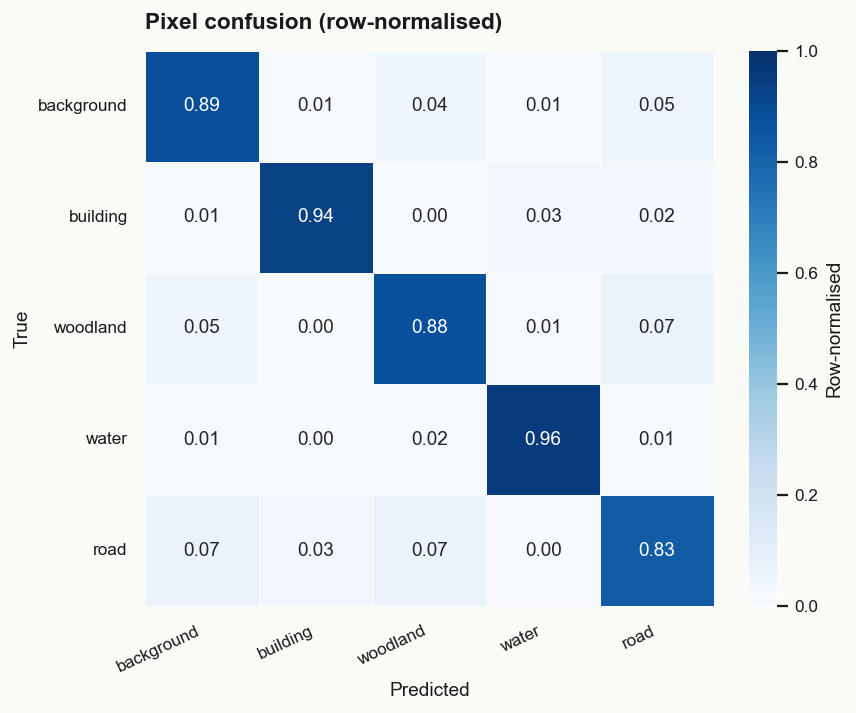

In [8]:
fig, ax = plt.subplots(figsize=(6.8, 5.6))
sp.pixel_confusion(conf, ax=ax)
plt.tight_layout(); plt.show()

**What to look at.** Row-normalised pixel confusion: each row is a true
class, each column where its pixels were predicted to go. The diagonal is
per-class recall.

**What it means.** The diagonal is high *everywhere* — including the rare
classes, where building and road recall stay high (0.94 and 0.83). So the model is
**not missing** them. The cost lives in the other direction (the precision
column of the §4 printout): having been told via the loss weights that
rare classes matter, the network errs toward **over-painting** roads and
buildings, absorbing background and woodland pixels as false positives.
That recall-up / precision-down trade is what holds their IoU down, and it
is a **knob, not a flaw** — shift the class weights toward precision if a
downstream map cares more about not crying wolf than about catching every
last rare pixel. The errors are concentrated and *explainable*, which is
what makes the next experiment obvious: more labelled rare-class pixels and
multispectral bands to separate materials RGB cannot.

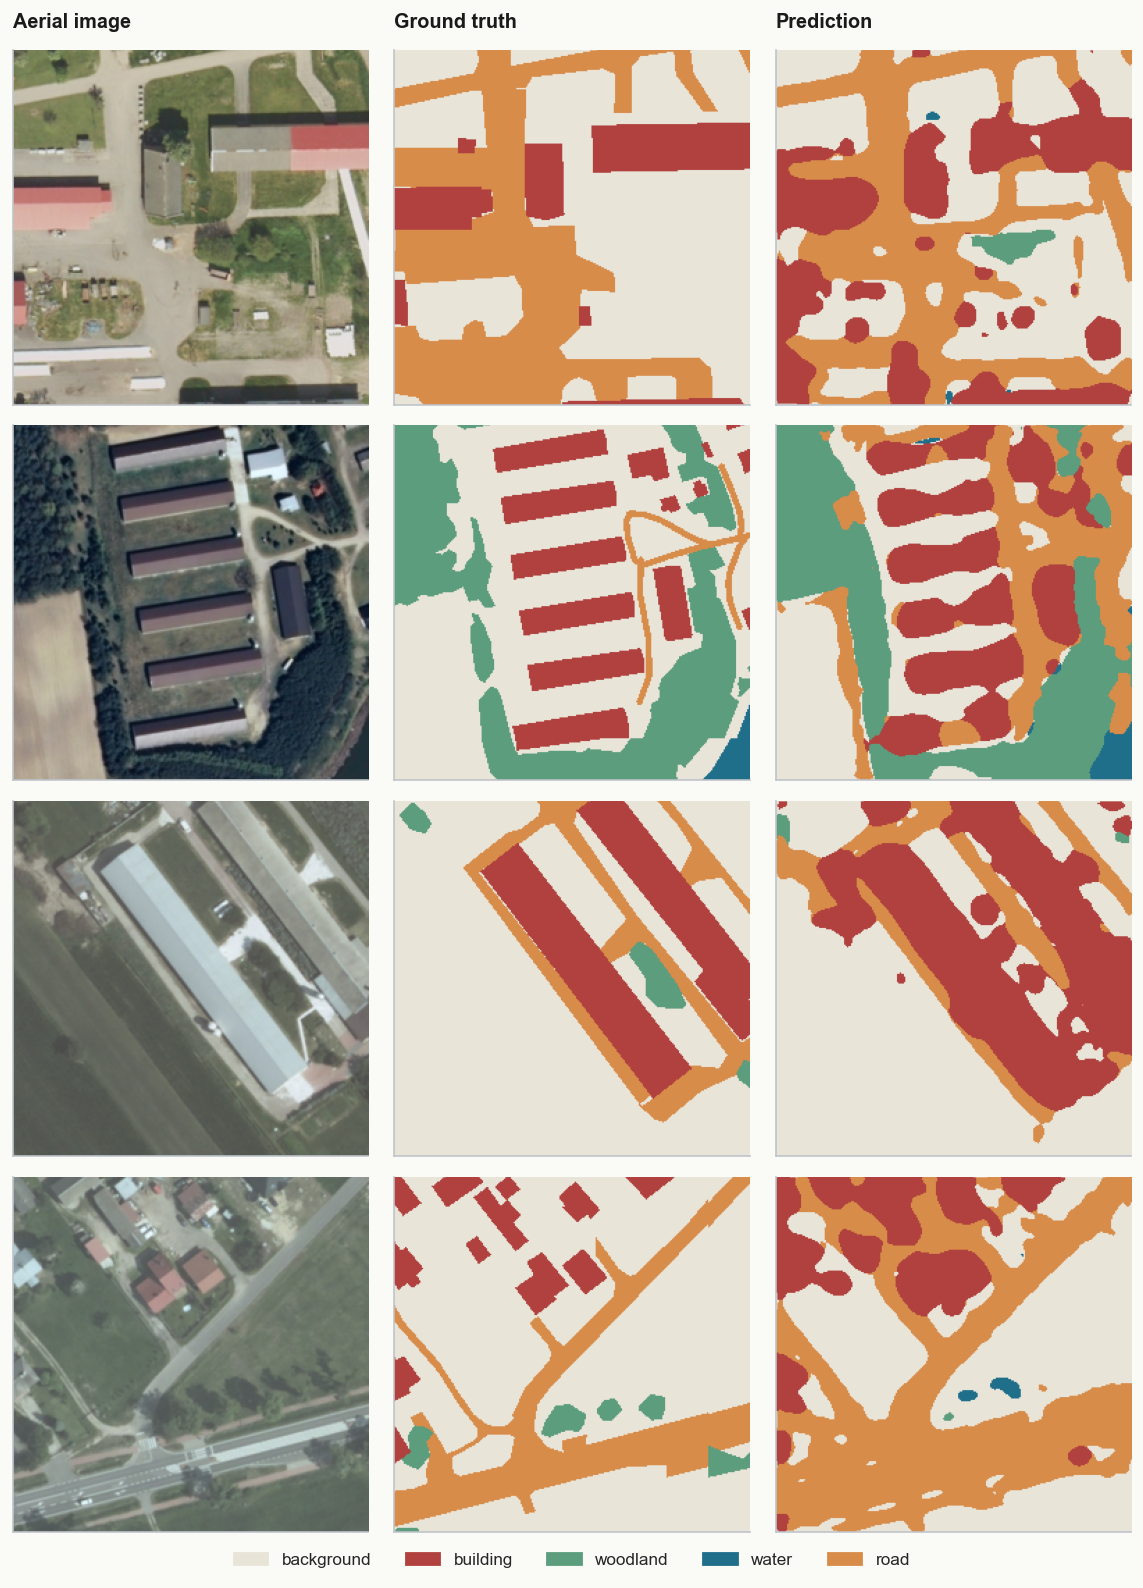

In [9]:
# Pick test tiles that show the model on the *hard, diverse* cases:
# those containing the rare building/road classes, with several classes present.
import numpy as np
from PIL import Image
import os
def info_score(stem):
    mk = np.asarray(Image.open(os.path.join(cache, "test", f"{stem}_m.png")))
    rare = float(np.isin(mk, [1, 4]).mean())   # building + road pixel share
    diversity = len(np.unique(mk))             # distinct classes present
    return diversity + 8 * rare
ranked = sorted(range(len(test_ds)),
                key=lambda i: info_score(test_ds.ids[i]), reverse=True)
fig = sp.prediction_triptych(model, test_ds, ranked[:4], DEVICE, max_rows=4)
plt.show()

**What to look at.** Four test tiles — chosen for containing the
hard, rare classes — shown as aerial image, ground-truth mask, and the
model's prediction.

**What it means.** The model recovers the **shape** of the scene: woodland
blocks, water bodies and the broad background are placed correctly and
their boundaries are clean. Where it struggles is exactly where the IoU
bars and the confusion matrix said it would — the thin connected
structures (roads) and small objects (buildings), which are a few hundred
pixels in a 65,000-pixel tile. Crucially, the failures are **honest and
legible**: you can see *why* a hedgerow-shadowed road was missed, which is
what makes the model debuggable and the next experiment obvious.

## 5. Conclusion

*What this proves, and how the two notebooks fit together.*

This notebook took the same problem the tabular analysis ran out of road
on — telling apart land-cover classes that covariates cannot separate —
and showed the capability that resolves it: **deep-learning semantic
segmentation of high-resolution aerial imagery, end to end in PyTorch**. A
U-Net with an ImageNet-pretrained ResNet-34 encoder, fine-tuned on ~1,200
tiles, learns to paint a five-class land-cover map at the pixel level,
with the difficulty falling — predictably and measurably — on the rare
classes.

**The discipline is the throughline, not the dataset.** Both notebooks
refuse the easy headline metric (accuracy → macro-F1; pixel accuracy →
mIoU), both confront class imbalance directly (minority species; rare
land-cover pixels), both validate against unseen geography rather than
shuffled neighbours, and both end by naming the *specific*, data-bound
reason for the residual error rather than reaching for a bigger model.

**Together they are a two-pillar portfolio:**

- **Pillar 1 — classical ML + applied statistics** ([`notebook.ipynb`](notebook.ipynb)):
  feature-driven modelling, model-family escalation, calibration and
  predictive uncertainty, and spatial cross-validation — the judgement of
  *when a simple model is the right one* and *how honestly to report it*.
- **Pillar 2 — deep-learning computer vision** (this notebook): PyTorch
  segmentation on aerial imagery, transfer learning, raster tiling, and
  rare-class-aware evaluation — the capability that scales to landscape-
  level monitoring.

**Honest limitations, and where this goes next.** The training budget here
is deliberately small; the validation curve was still rising, so the first
lever is simply more labelled tiles and epochs. Beyond that, the moves that
matter for a production ecological platform are the ones the tabular
notebook also pointed to: **multispectral and higher-resolution inputs**
(to separate species and materials RGB cannot), **larger tile context**,
and **uncertainty-aware inference** so that the low-confidence pixels —
the roads, the boundaries, the rare lifeforms — are the ones routed to a
human, exactly as the calibrated random forest's confident-tier triage did
in §4.6. The architecture changes; the engineering judgement does not.